In [18]:
import pandas as pd # import biblioteki pozwalającej na wczytanie danych w formie ramki danych, na których możem wykonywac proste operacje 
import re #biblioteka pozwalająca na wyszukiwania wyrażeń regularnych w tekście
import nltk
nltk.download('stopwords') #ściągnięcie słownika z wyrazami nie niosącymi znaczenia tzw.stopwords
nltk.download('wordnet')
from nltk.corpus import stopwords #import biblioteki, która posiada słownik z stopwordsami
import matplotlib.pyplot as plt #blioteka pozwalająca na wizualizacje danych
from matplotlib import cm #import palety kolorów biblioteki matplotlib
import seaborn as sns #blioteka pozwalająca na wizualizacje danych
from wordcloud import WordCloud #biblioteka pozwalającca na tworzenie chmury słów
from nltk.stem import PorterStemmer #biblioteka pozwalajaca na stemantyzację
from nltk.stem.wordnet import WordNetLemmatizer #biblioteka pozwalajaca na lemantyzację
import collections # biblioteka pozwalająca na zliczanie słów, bigramów, trigramów
from nltk import bigrams #biblioteka do tworzenia bigramów
import pickle #biblioteka do tworzenia i otwierania plików w formacie pickle
import stylecloud #biblioteka do tworzenia chmury słów
from googletrans import Translator #biblioteka do tłumaczenia napisanego tekstu na inny język lub detekcji języka
from nltk import pos_tag
plt.style.use("seaborn-v0_8-whitegrid")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nataliakurczynska/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/nataliakurczynska/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
data = pd.read_csv("data_clean.csv", index_col = 0)

In [20]:
#jezeli w wiersz jest postem to ma tylko title, nie ma body
((data["type"]=="posts") & (data["body"].notna())).any()
#jezeli wiersz jest komentarzem to ma tylko body, nie ma title
((data["type"]=="comment") & (data["title"].notna())).any()

#krocej zapisane ze nie ma takiego wiersza w ktorym i w kolumnie title i body jest cokolwiek
((data["title"].notna()) & (data["body"].notna())).any()

False

In [21]:
data["tresc"] = data[["title","body"]].fillna("").agg(" ".join, axis=1).str.strip() #łączy nam tekst z obu kolumn w jedna kolumne "tresc"

# ANALIZA DLA HANNAH MONTANA

In [22]:
data_hannah = data[data["subreddit"]=="hannahmontana"]
data_hannah["year"].value_counts()

year
2026    10800
2025     3780
2024     1523
2023      547
2020       42
2022       31
2019       23
2017        9
2021        6
2015        5
2018        5
2013        1
2014        1
2016        1
Name: count, dtype: int64

In [23]:
#OBCINAMY OD ROKU 2024 DO 2026
data_hannah = data[(data["subreddit"]== "hannahmontana") & (data["year"] >= 2024)]
data_hannah.head(5)

,type,subreddit,date,year,id,parent_id,author,title,body,score,over_18,tresc
7877,comments,hannahmontana,2024-01-01,2024,kfvdwr9,18fsuvk,ArcticHM,NaN,This is weirder than a three eyed billygoat in...,1,NaN,This is weirder than a three eyed billygoat in...
7878,comments,hannahmontana,2024-01-06,2024,kgl1zfb,18i3a3a,Dramatic_Scholar9385,NaN,"I think so in Hannah Montana: The Movie, Miley...",1,NaN,"I think so in Hannah Montana: The Movie, Miley..."
7879,comments,hannahmontana,2024-01-07,2024,kgp64y6,190iy7o,Ill-Glass4212,NaN,"I said it before, but I won't say 100% that Ja...",-2,NaN,"I said it before, but I won't say 100% that Ja..."
7880,comments,hannahmontana,2024-01-07,2024,kgql84f,190iy7o,raighsunshine,NaN,season 1 & 2 is superior enough said,4,NaN,season 1 & 2 is superior enough said
7881,comments,hannahmontana,2024-01-07,2024,kgr9st7,18admlw,Comfortable-Hall1178,NaN,"There was gonna be a new Lizzie McGuire show, ...",1,NaN,"There was gonna be a new Lizzie McGuire show, ..."


In [24]:
data_hannah_df = pd.DataFrame(data_hannah, columns=['tresc'])
data_hannah_df.head(5)

,tresc
7877,This is weirder than a three eyed billygoat in...
7878,"I think so in Hannah Montana: The Movie, Miley..."
7879,"I said it before, but I won't say 100% that Ja..."
7880,season 1 & 2 is superior enough said
7881,"There was gonna be a new Lizzie McGuire show, ..."


In [25]:
dictionary = {
    "dont": "don't",
    "doesnt": "doesn't",
    "didnt": "didn't",
    "wasnt": "wasn't",
    "werent": "weren't",
    "shes": "she's",
    "ive": "i've",
    "cant": "can't",
    "hes": "he's",
    "isnt": "isn't",
    "arent": "aren't",
    "thats": "that's",
    "wouldve": "would've",
    "youre": "you're"
}

def normalize_text(text):
    new_words = text.split()
    new_words = [dictionary.get(w, w) for w in new_words]
    return " ".join(new_words)

In [26]:
#Usuwanie stopwords
def remove_my_stopwords(text):
    stop_words = stopwords.words("english") 
    stop_words.extend(["oah", "haha", "hey", "yeah", "oh", "lol", "omg", "ain't", "im", "hannah", "montana", "miley", "would", "could","can't", "also", "else", "that's", "would've"])
    filtred_words=[]
    for word in text.split():
        if word not in stop_words:
            filtred_words.append(word)
    return filtred_words

In [28]:
data_hannah_string = " ".join(data_hannah_df['tresc'].fillna(""))

In [29]:
#oczyszczenie
import emoji

data_hannah_df['tresc'] = data_hannah_df['tresc'].fillna("")
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: str(x).lower())
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(normalize_text)
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: remove_my_stopwords(x))
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: " ".join(x))

In [30]:
data_hannah_str = data_hannah_df['tresc'].fillna("").str.lower().str.split().explode().dropna().tolist()

['weirder',
 'three',
 'eyed',
 'billygoat',
 'flatbed',
 'truck',
 'middle',
 'manhattan',
 'think',
 'movie',
 'ended',
 'travis',
 'said',
 'say',
 'jake',
 'cheater',
 'photo',
 'even',
 'imply',
 'anything',
 'fact',
 'cases',
 'cheated',
 'less',
 'maybe',
 'emotional',
 'gah',
 'season',
 'superior',
 'enough',
 'said',
 'gonna',
 'new',
 'lizzie',
 'mcguire',
 'show',
 'got',
 'scrapped',
 'doubt',
 'another',
 'series',
 'went',
 'great',
 'lengths',
 'remove',
 'series',
 'chose',
 'make',
 'another',
 'show',
 'id',
 'watch',
 'even',
 'though',
 'way',
 'old',
 'shows',
 'birthday',
 'year',
 'younger',
 'agree',
 'long',
 'straight',
 'wig',
 'much',
 'better',
 'medium',
 'wavy',
 'one',
 'season',
 'episode',
 'judge',
 'tender',
 'jake',
 'never',
 'together',
 'love',
 'interest',
 'genuine',
 'intentions',
 'loved',
 'yes',
 'actually',
 'worked',
 'tell',
 'loved',
 'movie',
 'like',
 'something',
 'nebraska',
 'right',
 'state',
 'tennessee',
 'name',
 'state',
 'pa

<Axes: xlabel='slowa'>

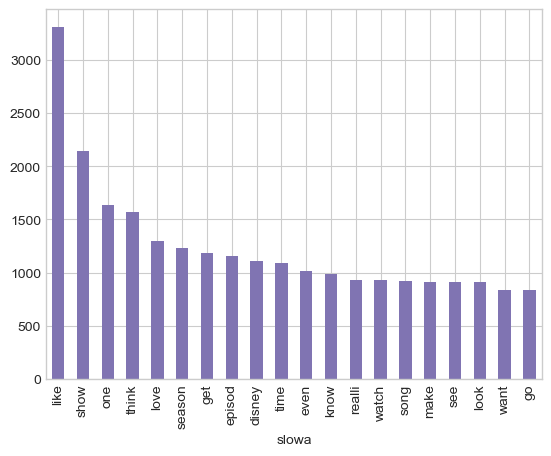

In [31]:
#proces stemantyzacji - sprowadzanie słów do ich rdzeni
ps = PorterStemmer()
stemmed_words = []

for word in data_hannah_str:
    stemmed_words.append(ps.stem(word))

lista_slow_stem = pd.DataFrame(stemmed_words)
lista_slow_stem.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_stem.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")

In [32]:
lista_slow_stem.slowa.value_counts().head(40)

slowa
like       3312
show       2139
one        1639
think      1566
love       1297
season     1232
get        1183
episod     1159
disney     1107
time       1086
even       1014
know        991
realli      930
watch       929
song        916
make        915
see         914
look        907
want        840
go          839
got         837
movi        836
special     818
peopl       803
year        769
say         759
feel        734
still       714
thing       675
much        672
rememb      672
fan         632
back        604
never       604
life        588
alway       586
way         581
made        581
actual      570
cast        568
Name: count, dtype: int64

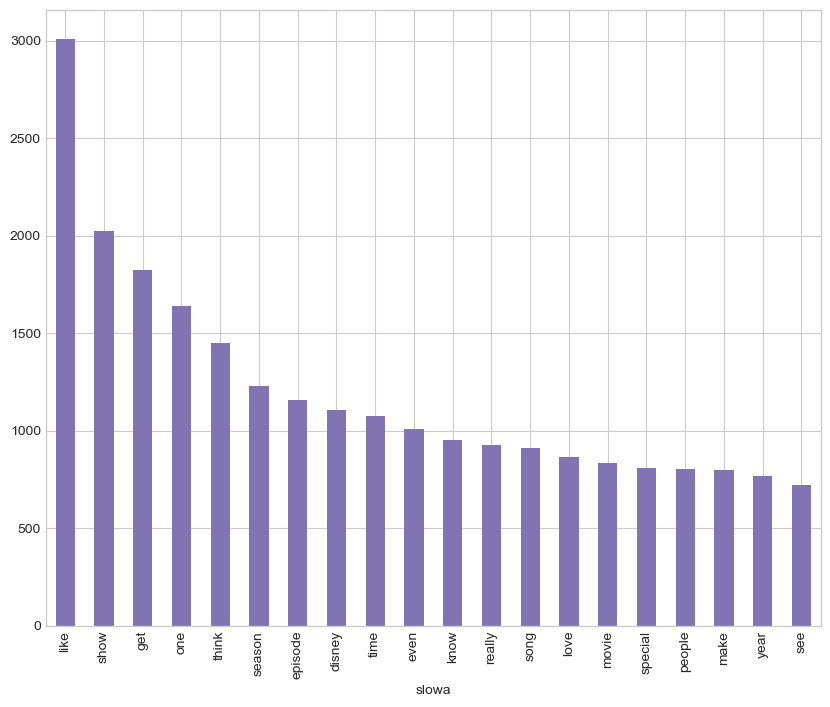

In [33]:
#Lemnatyzacja - sprowadzenie słów do wersji podstawowej
wnl = WordNetLemmatizer()

lemmed_words = []

for word in data_hannah_str:
    lemmed = wnl.lemmatize(word)
    lemmed_words.append("get" if lemmed == "got" else lemmed)
                        
lista_slow_lem = pd.DataFrame(lemmed_words)
lista_slow_lem.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_lem.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")
plt.gcf().set_size_inches(10, 8)
plt.savefig('ranking_lematy.png', dpi = 300)

In [34]:
from nltk.corpus import wordnet
from nltk import pos_tag

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

tagged_words = pos_tag(data_hannah_str)
my_list = []
for word, tag in tagged_words:
    lemma = wnl.lemmatize(word, get_wordnet_pos(tag))
    my_list.append(lemma)

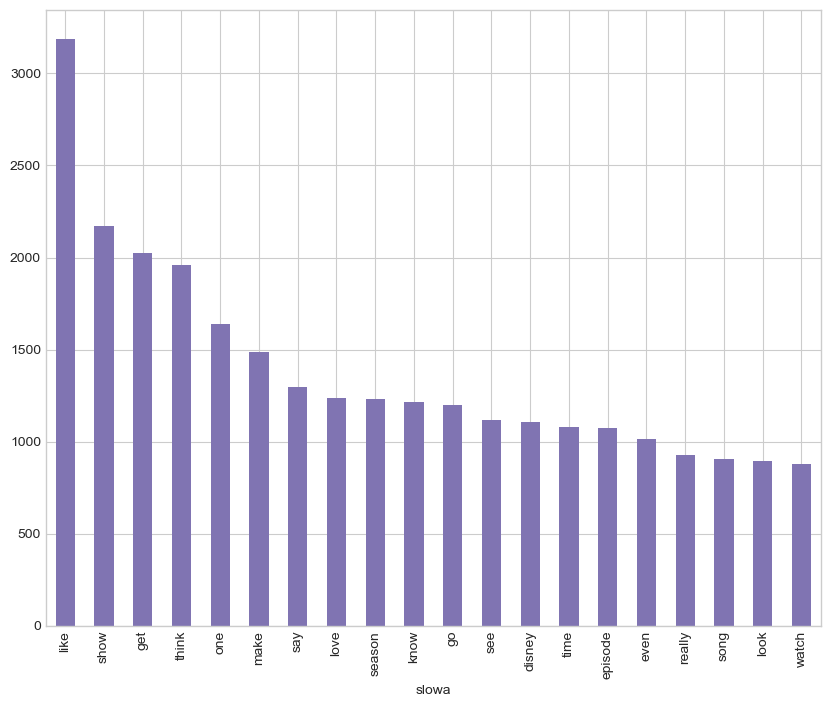

In [35]:
lista_slow_lem = pd.DataFrame(my_list)
lista_slow_lem.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_lem.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")
plt.gcf().set_size_inches(10, 8)
plt.savefig('ranking_lematy.png', dpi = 300)

In [36]:
len(lista_slow_lem)

176952

In [37]:
lista_slow_lem.slowa.value_counts().head(40)

slowa
like        3185
show        2169
get         2025
think       1958
one         1639
make        1486
say         1299
love        1239
season      1232
know        1215
go          1201
see         1118
disney      1106
time        1080
episode     1076
even        1013
really       930
song         906
look         897
watch        881
movie        836
special      809
people       803
want         799
year         769
still        714
feel         677
thing        675
much         672
good         665
remember     663
come         653
old          631
fan          631
life         611
never        604
back         601
well         597
always       585
way          581
Name: count, dtype: int64

## LISTA TOP SŁÓW 

In [38]:
df = pd.DataFrame(data_hannah_df, columns = ['tresc'])
df.head()

,tresc
7877,weirder three eyed billygoat flatbed truck mid...
7878,think movie ended travis
7879,said say jake cheater photo even imply anythin...
7880,season superior enough said
7881,gonna new lizzie mcguire show got scrapped dou...


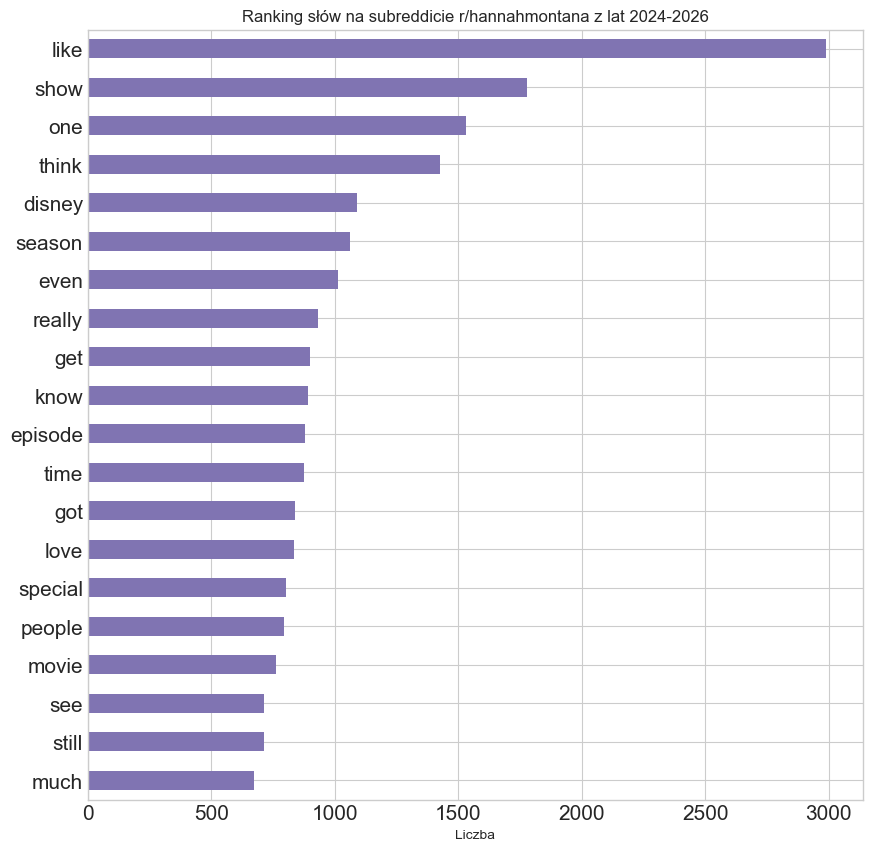

In [22]:
#statystyka częstości występowania słów w postach/komentarzach ze slowek hannahmontana
words = pd.DataFrame(data_hannah_str).value_counts().head(20).rename_axis("słowo").reset_index(name="liczba")

ax1 = words.sort_values(by='liczba').plot.barh(x='słowo',y='liczba', figsize=(10,10), fontsize=15, title='Ranking słów na subreddicie r/hannahmontana z lat 2024-2026', color="#8074B2")
ax1.set_ylabel("");
ax1.set_xlabel("Liczba");
ax1.get_legend().remove()

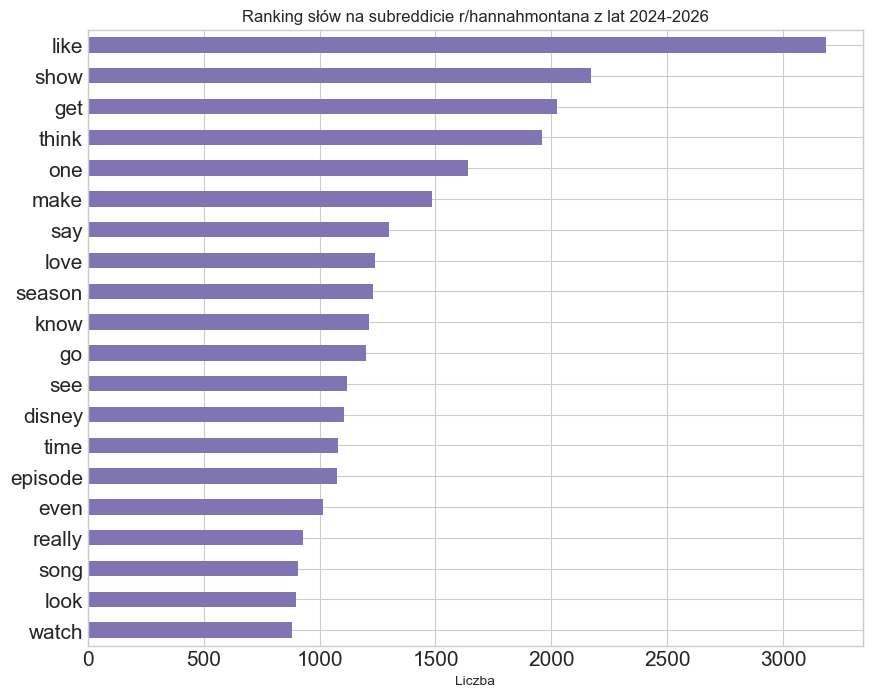

In [53]:
#statystyka częstości występowania słów w postach/komentarzach ze slowek hannahmontana
words = pd.DataFrame(my_list).value_counts().head(20).rename_axis("słowo").reset_index(name="liczba")

ax = words.sort_values(by='liczba').plot.barh(x='słowo',y='liczba', figsize=(10,10), fontsize=15, title='Ranking słów na subreddicie r/hannahmontana z lat 2024-2026', color="#8074B2")
ax.set_ylabel("");
ax.set_xlabel("Liczba");
ax.get_legend().remove()
plt.gcf().set_size_inches(10, 8)
plt.savefig('ranking_slow.png', dpi = 300)

## CHMURA SŁÓW

In [24]:
word_cloud_words = pd.DataFrame(data_hannah_str).value_counts().head(80).rename_axis("word").reset_index(name="count")
word_cloud_words
wystapienia_hannah = dict(zip(word_cloud_words["word"], word_cloud_words["count"]))
wystapienia_hannah

{'like': 2989,
 'show': 1778,
 'one': 1533,
 'think': 1428,
 'disney': 1091,
 'season': 1062,
 'even': 1011,
 'really': 930,
 'get': 899,
 'know': 892,
 'episode': 881,
 'time': 877,
 'got': 837,
 'love': 836,
 'special': 801,
 'people': 796,
 'movie': 762,
 'see': 715,
 'still': 712,
 'much': 672,
 'remember': 630,
 'never': 604,
 'back': 592,
 'always': 585,
 'made': 581,
 'life': 568,
 'way': 557,
 'good': 551,
 'first': 541,
 'said': 540,
 'song': 530,
 'feel': 525,
 'make': 524,
 'cast': 522,
 'thought': 511,
 'something': 497,
 'best': 497,
 'old': 472,
 'go': 472,
 'years': 470,
 'lot': 454,
 'actually': 435,
 'felt': 429,
 'say': 407,
 'jackson': 404,
 'thing': 403,
 'loved': 399,
 'yes': 396,
 'songs': 385,
 'right': 384,
 'well': 383,
 'real': 379,
 'wanted': 376,
 'sure': 371,
 'going': 367,
 'girl': 360,
 'maybe': 360,
 'cyrus': 359,
 'want': 357,
 'alex': 357,
 'anniversary': 349,
 'look': 346,
 'watch': 343,
 'ray': 340,
 'new': 338,
 'since': 337,
 'fans': 336,
 'whole':

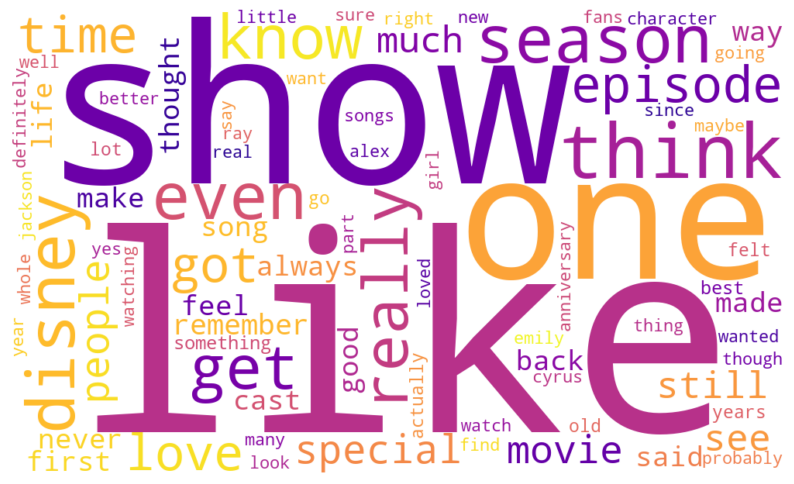

In [25]:
plt.figure(figsize=(10,10))
wc= WordCloud(background_color ='white', max_words = 80, width=1000, height=600, colormap = cm.plasma).generate_from_frequencies(wystapienia_hannah)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off');

In [26]:
import numpy as np
from PIL import Image

In [27]:
mask = np.array(Image.open("hannahmontana mask.png").convert("L"))
mask = np.where(mask > 100, 255, 0)

In [28]:
colors = ["#dabcff","#deacde","#9e4a9e","#ffc370","#ffc6d0","#800080","#b266b2","#a64ca6","#b266b2"]
color_function = lambda *args, **kwargs: np.random.choice(colors)

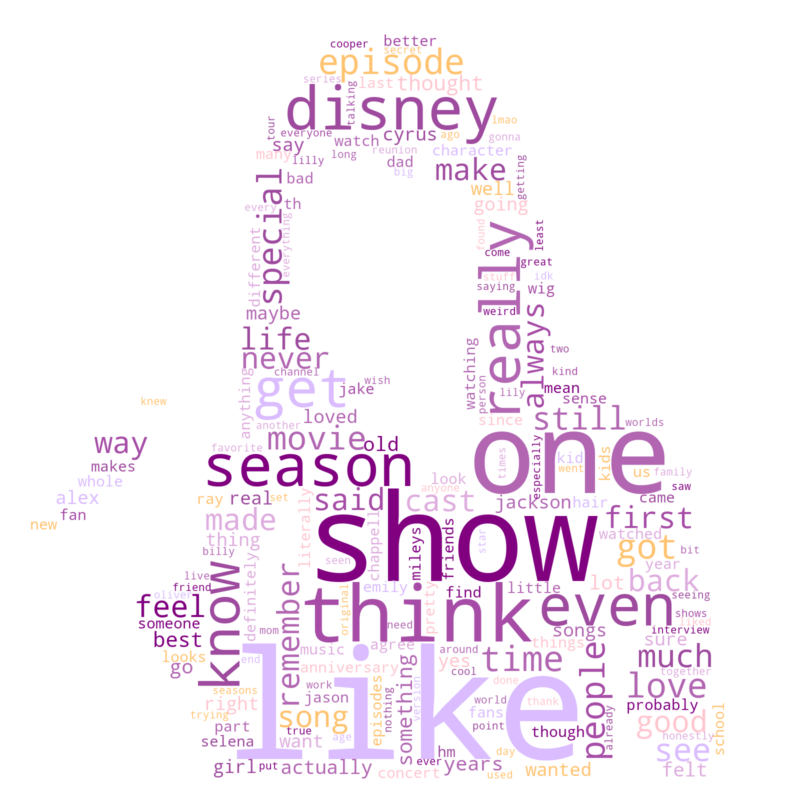

In [29]:
word_cloud_words = pd.DataFrame(data_hannah_str).value_counts().head(200).rename_axis("word").reset_index(name="count")
word_cloud_words
wystapienia_hannah = dict(zip(word_cloud_words["word"], word_cloud_words["count"]))
wystapienia_hannah
plt.figure(figsize=(10,10))
wc= WordCloud(background_color ="white", mask=mask,scale = 1.5,color_func=color_function, max_words = 190, width=1000, height=600, colormap = cm.plasma).generate_from_frequencies(wystapienia_hannah)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off');

In [30]:
word_cloud_words = pd.DataFrame(my_list).value_counts().head(200).rename_axis("word").reset_index(name="count")
word_cloud_words
wystapienia_hannah = dict(zip(word_cloud_words["word"], word_cloud_words["count"]))
wystapienia_hannah
plt.figure(figsize=(10,10))
wc= WordCloud(background_color = None, mode = "RGBA", mask=mask,scale = 1.5,color_func=color_function, max_words = 190, width=1000, height=600, colormap = cm.plasma).generate_from_frequencies(wystapienia_hannah)
#plt.imshow(wc, interpolation='bilinear')
#plt.axis('off')
wc_img = wc.to_image().convert("RGBA")
wc_img.save("hannah_no.png")

<Figure size 1000x1000 with 0 Axes>

In [31]:
img = Image.open("hannahmontana mask-kopia.png").convert("RGB")
arr = np.array(img)

#zeby tło to był taki beżowy/cielisty kolor
grey = np.array([249, 249, 249])

mask = arr.mean(axis=2) < 250
arr[mask] = arr[mask] * 0.05 + grey * 0.95

out = Image.fromarray(arr)
out.save("output.png")

In [32]:
#tło
background = Image.open("output.png").convert("RGBA")

#stworzony wczesniej wordcloud
wordcloud = Image.open("hannah_no.png").convert("RGBA")

wordcloud = wordcloud.resize(background.size)
#wordcloud.putalpha(180)

result = Image.alpha_composite(background, wordcloud)

result.save("final.png")

## ANALIZA WYDŹWIĘKU

In [33]:
from textblob import TextBlob
from nltk.corpus import stopwords, twitter_samples
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import seaborn as sns
import numpy as np
import re
import matplotlib.pyplot as plt
import pandas as pd
import nltk

In [34]:
from nltk.corpus import stopwords

stop = set(stopwords.words("english"))

safe_stopwords = stop - {
    "not", "no", "nor",
    "don't", "didn't", "wasn't", "won't", "can't",
    "isn't", "aren't", "couldn't", "wouldn't"
}

In [35]:
df = pd.DataFrame(data_hannah, columns=['tresc'])
df.head()

,tresc
7877,This is weirder than a three eyed billygoat in...
7878,"I think so in Hannah Montana: The Movie, Miley..."
7879,"I said it before, but I won't say 100% that Ja..."
7880,season 1 & 2 is superior enough said
7881,"There was gonna be a new Lizzie McGuire show, ..."


In [36]:
#Usuwanie stopwords
def remove_my_stopwords(text):
    stop_words = safe_stopwords
    stop_words.update({"oah", "haha", "hey", "yeah", "oh", "lol", "omg", "im"})
    filtred_words=[]
    for word in text.split():
        if word not in stop_words:
            filtred_words.append(word)
    return filtred_words

In [37]:
#oczyszczenie
import emoji

df['tresc'] = df['tresc'].fillna("")
df['tresc'] = df['tresc'].apply(lambda x: str(x).lower())
df['tresc'] = df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
df['tresc'] = df['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
df['tresc'] = df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
df['tresc'] = df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
df['tresc'] = df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
df['tresc'] = df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
df['tresc'] = df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
df['tresc'] = df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
df['tresc'] = df['tresc'].apply(normalize_text)
df['tresc'] = df['tresc'].apply(lambda x: remove_my_stopwords(x))
df['tresc'] = df['tresc'].apply(lambda x: " ".join(x))

In [38]:
hannah_sentiment = df['tresc'].fillna("").str.lower().str.split().explode().dropna()

In [39]:
tekst = " ".join(hannah_sentiment)

"weirder three eyed billygoat flatbed truck middle manhattan think hannah montana movie miley ended travis said won't say jake cheater photo didn't even imply anything fact cases miley cheated less maybe emotional gah season superior enough said gonna new lizzie mcguire show got scrapped doubt another hannah montana series miley went great lengths remove series chose make another show id watch even though way old shows also birthday miley year younger agree long straight wig much better medium wavy one season episode judge tender jake miley never together love interest genuine intentions loved miley yes actually would worked tell loved movie like something nebraska right state tennessee name state party last name tennessee bucky kentucky oliver feel alaska nebraska bucky kentucky bucky kentucky bucky kentucky movie set sesons stopped reading moment saw jesse erasure wdym engaged jake broke jesse don't disrespect like like jesse way better jake need money popularity boost sell album not

In [40]:
wystapienia = [] #utworzenie pustej listy

with open('pozytywne_slowa.txt') as file: #otworzenie pliku tekstoweo z pozytywnymi słowami
    pozytywne_slowa = file.read().split('\n') #zapisanie pozytywnych słów do zmiennej

    for slowo in pozytywne_slowa: #pętl po słowach pozytywnych
        wystapienia.append(tekst.count(slowo.strip())) #zliczenie słów pozytywnych w tekście za pomocą funkcji count
        
pozytywne_slowa_wystapienia = pd.DataFrame(wystapienia, index=pozytywne_slowa, columns=['liczba']) #zapisanie występujących pozytywnych słów do ramki danych

In [41]:
pozytywne_conjamniej_raz = pozytywne_slowa_wystapienia[pozytywne_slowa_wystapienia.liczba >1]
pozytywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)

,liczba
,1292061
like,3356
love,1317
good,613
best,515
...,...
improved,2
striking,2
darling,2
steady,2


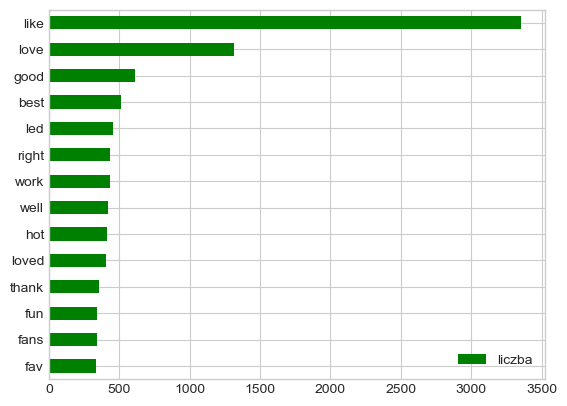

In [42]:
pozytywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)[1:15].plot(kind = 'barh', color = 'green')
plt.gca().invert_yaxis()

In [43]:
wystapienia = [] #utworzenie pustej listy

with open('negatywne_slowa.txt', encoding = "latin1") as file: #otworzenie pliku tekstoweo z pozytywnymi słowami
    
    negatywne_slowa = file.read().split('\n') #zapisanie pozytywnych słów do zmiennej

    for slowo in negatywne_slowa: #pętl po słowach pozytywnych
        wystapienia.append(tekst.count(slowo.strip())) #zliczenie słów pozytywnych w tekście za pomocą funkcji count
        
negatywne_slowa_wystapienia = pd.DataFrame(wystapienia, index=negatywne_slowa, columns=['liczba']) #zapisanie występujących pozytywnych słów do ramki danych

In [44]:
negatywne_conjamniej_raz = negatywne_slowa_wystapienia[negatywne_slowa_wystapienia.liczba >1]
negatywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)

,liczba
,1292061
ugh,1455
sin,1201
mad,665
din,645
...,...
madness,2
exaggeration,2
bugs,2
indulge,2


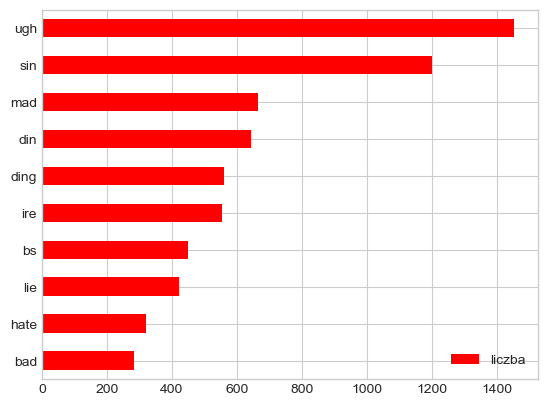

In [45]:
negatywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)[1:11].plot(kind = 'barh', color = 'red')
plt.gca().invert_yaxis()

In [46]:
#VADER

In [47]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
sia.lexicon
data_hannah["tresc"] = data_hannah['tresc'].apply(normalize_text)
data_hannah["tresc"] = data_hannah['tresc'].apply(lambda x: re.sub(r"http\S+|www\S+", "", x)) #linki, strony internetowe
data_hannah["tresc"] = data_hannah['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_hannah["vader"] = data_hannah['tresc'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
data_hannah.head()

/var/folders/nv/6k4klf9570d71xlr82yxfpw40000gn/T/ipykernel_32215/622457032.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_hannah["tresc"] = data_hannah['tresc'].apply(normalize_text)
/var/folders/nv/6k4klf9570d71xlr82yxfpw40000gn/T/ipykernel_32215/622457032.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_hannah["tresc"] = data_hannah['tresc'].apply(lambda x: re.sub(r"http\S+|www\S+", "", x)) #linki, strony internetowe
/var/folders/nv/6k4klf9570d71xlr82yxfpw40000gn/T/ipykernel_32215/622457

,type,subreddit,date,year,id,parent_id,author,title,body,score,over_18,tresc,vader
7877,comments,hannahmontana,2024-01-01,2024,kfvdwr9,18fsuvk,ArcticHM,NaN,This is weirder than a three eyed billygoat in...,1,NaN,This is weirder than a three eyed billygoat in...,-0.1280
7878,comments,hannahmontana,2024-01-06,2024,kgl1zfb,18i3a3a,Dramatic_Scholar9385,NaN,"I think so in Hannah Montana: The Movie, Miley...",1,NaN,"I think so in Hannah Montana: The Movie, Miley...",0.0000
7879,comments,hannahmontana,2024-01-07,2024,kgp64y6,190iy7o,Ill-Glass4212,NaN,"I said it before, but I won't say 100% that Ja...",-2,NaN,"I said it before, but I won't say 100% that Ja...",-0.9127
7880,comments,hannahmontana,2024-01-07,2024,kgql84f,190iy7o,raighsunshine,NaN,season 1 & 2 is superior enough said,4,NaN,season 1 & 2 is superior enough said,0.5423
7881,comments,hannahmontana,2024-01-07,2024,kgr9st7,18admlw,Comfortable-Hall1178,NaN,"There was gonna be a new Lizzie McGuire show, ...",1,NaN,"There was gonna be a new Lizzie McGuire show, ...",0.5267


<Axes: >

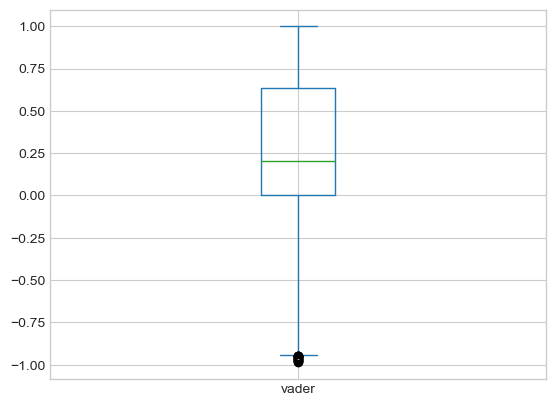

In [48]:
data_hannah['vader'].plot.box()

<Axes: ylabel='vader'>

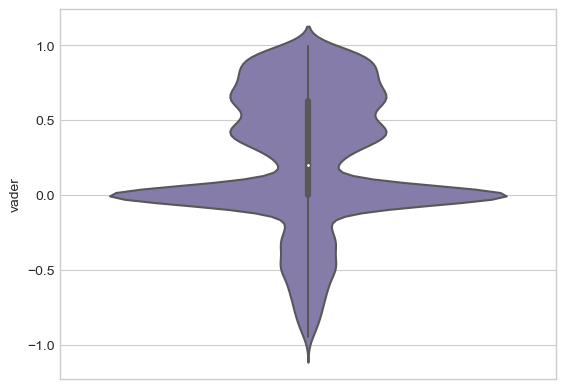

In [49]:
sns.violinplot(y=data_hannah['vader'], color = "#8074B2")

In [50]:
data_hannah.loc[:, "label"] = data_hannah["vader"].apply(
    lambda x: "Pozytywny" if x >= 0.05 else
              "Negatywny" if x <= -0.05 else
              "Neutralny"
)

/var/folders/nv/6k4klf9570d71xlr82yxfpw40000gn/T/ipykernel_32215/3919681947.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_hannah.loc[:, "label"] = data_hannah["vader"].apply(


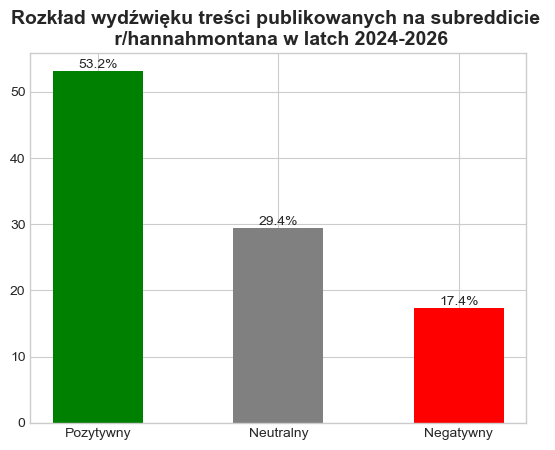

In [57]:
counts = data_hannah["label"].value_counts(normalize=True) * 100


bars = plt.bar( counts.index, counts.values, color=["green", "gray", "red"], width = 0.5)

plt.style.use("seaborn-v0_8-whitegrid")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )
plt.title("Rozkład wydźwięku treści publikowanych na subreddicie \n r/hannahmontana w latch 2024-2026", fontsize=14, weight="bold")

plt.savefig("hannah_sentyment.png", dpi =300)
plt.show()

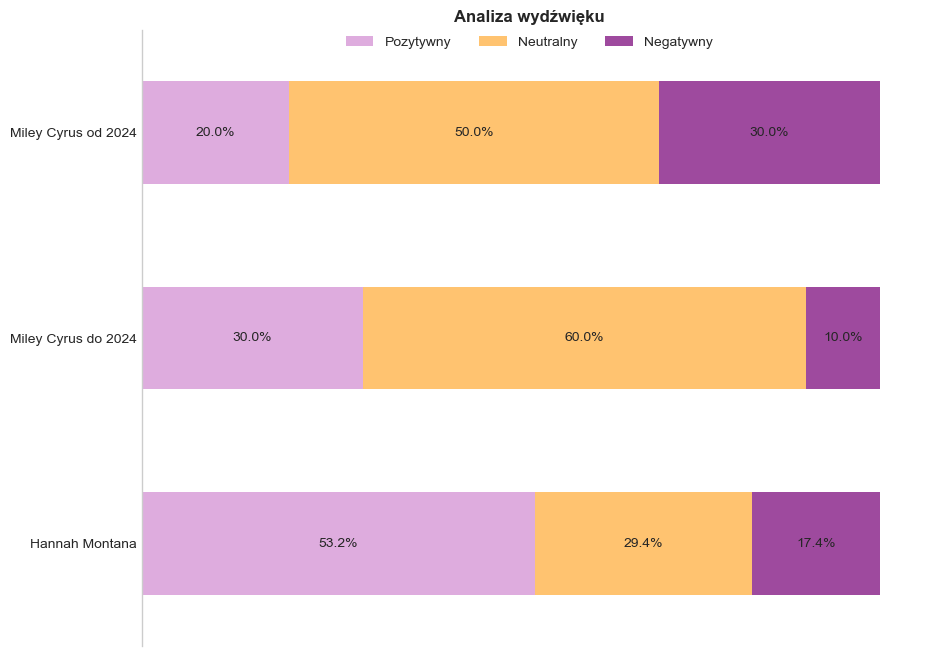

In [52]:
category_names = ["Pozytywny", "Neutralny", "Negatywny"]

colors = ["#deacde", "#ffc370","#9e4a9e"]

df = pd.DataFrame({
    "Pozytywny": [53.2, 30, 20],
    "Neutralny":[29.4, 60, 50],
    "Negatywny": [17.4, 10, 30]
}, index = ["Hannah Montana", "Miley Cyrus do 2024", "Miley Cyrus od 2024"])


ax = df.plot(kind = "barh",
             stacked = True,
             color = colors,
             figsize = (10,8))

for container in ax.containers:
    ax.bar_label(container,
                label_type = "center",
                labels = [f"{bar.get_width():.1f}%" for bar in container
    ])

ax.xaxis.set_visible(False)

ax.set_title("Analiza wydźwięku", fontweight = "bold")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=len(df.columns),
    frameon=False
)


plt.show()